In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("../data/raw/random_stock_market_dataset.csv")

In [4]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2024-01-01,296.45,307.31,293.96,303.72,93133
1,2024-01-02,190.11,193.10,187.21,191.40,64993
2,2024-01-03,197.41,208.64,193.37,205.89,70326
3,2024-01-04,253.13,262.67,248.67,258.95,17358
4,2024-01-05,241.35,253.09,238.99,252.20,20847


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    60 non-null     str    
 1   Open    60 non-null     float64
 2   High    60 non-null     float64
 3   Low     60 non-null     float64
 4   Close   60 non-null     float64
 5   Volume  60 non-null     int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 2.9 KB


In [6]:
df.describe()

,Open,High,Low,Close,Volume
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,310.552000,322.589833,308.056833,320.412667,95405.516667
std,108.859051,109.095813,108.986426,109.157159,54895.342146
min,112.680000,123.780000,109.430000,121.270000,13193.000000
25%,222.957500,238.247500,220.042500,237.242500,48016.500000
50%,303.240000,313.800000,302.385000,309.385000,93850.500000
75%,396.150000,415.915000,392.905000,413.462500,130917.250000
max,492.790000,501.670000,492.300000,500.420000,195189.000000


In [7]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [9]:
print(len(df))

60


In [10]:
df.tail()

,Date,Open,High,Low,Close,Volume
55,2024-02-25,170.55,181.13,167.39,178.58,47071
56,2024-02-26,187.88,195.26,186.36,193.36,115659
57,2024-02-27,355.67,375.14,353.60,370.56,62294
58,2024-02-28,289.90,298.27,289.06,298.01,108022
59,2024-02-29,120.34,131.84,116.30,129.95,64201


In [11]:
df.shape

(60, 6)

In [12]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='str')

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['Date'] = pd.to_datetime(df['Date'])

In [15]:
df['Date'].min(), df['Date'].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2024-02-29 00:00:00'))

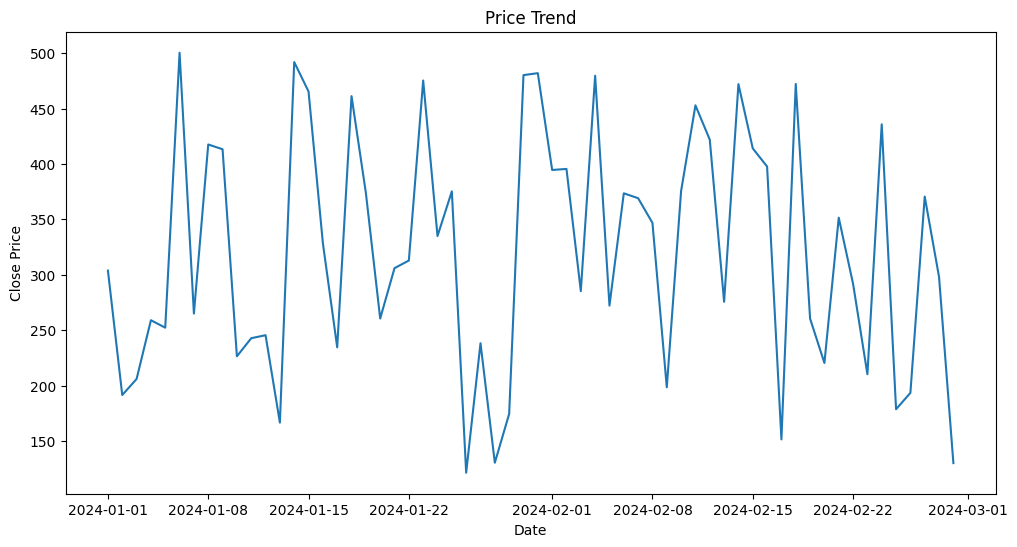

In [19]:
#price trend graph
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Price Trend')    
plt.show()

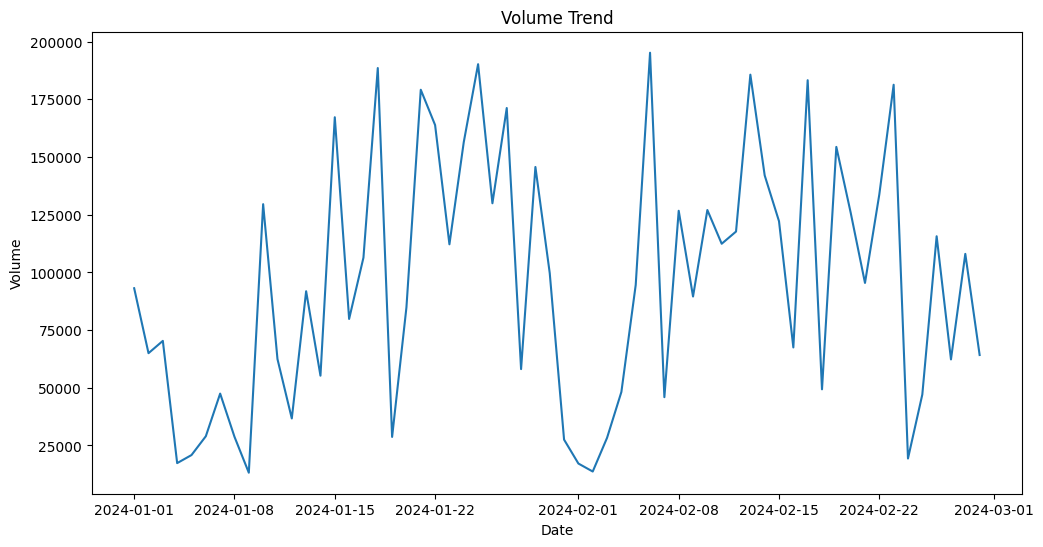

In [ ]:
#volume visualization
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Volume'])
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Volume Trend')
plt.show()

In [26]:
df['Open vs close'] = df['Close'] - df['Open']

In [28]:
print(df['Open vs close'].mean())

9.86066666666667


In [ ]:
#higher std deviation means more volatility
df['Close'].std()

np.float64(109.15715920784895)

In [32]:
df['daily_return'] = df['Close'].pct_change()
print("standard deviation of daily returns:", df['daily_return'].std())

standard deviation of daily returns: 0.6192865217446709


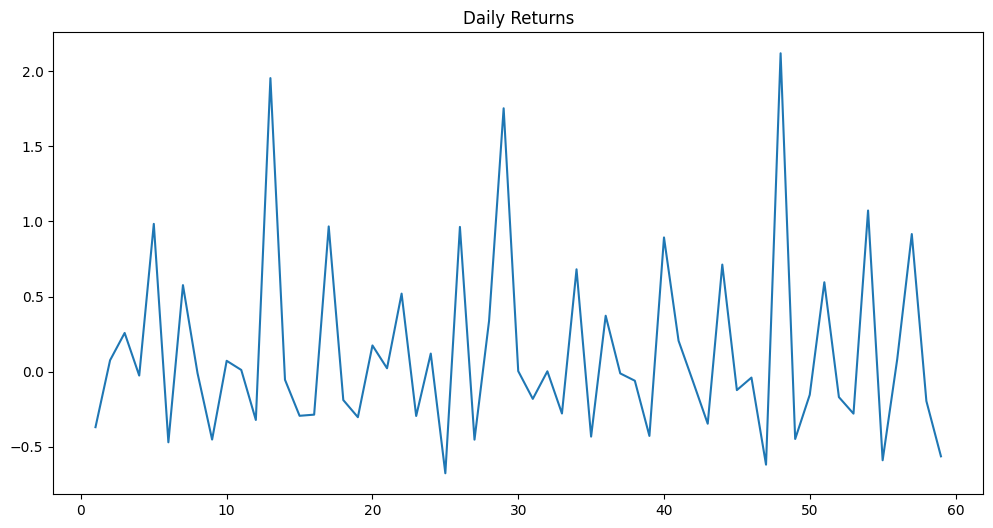

In [36]:
plt.figure(figsize=(12,6))
plt.plot(df['daily_return'])
plt.title("Daily Returns")
plt.show()

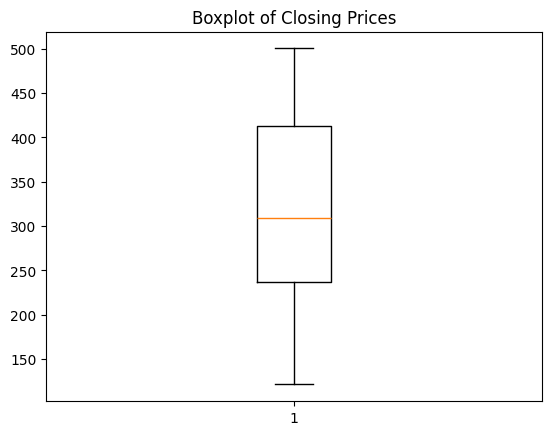

In [37]:
plt.boxplot(df['Close'])
plt.title("Boxplot of Closing Prices")
plt.show()

In [40]:
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Close'] < lower) | (df['Close'] > upper)]

print("outliers:", outliers.shape[0])

outliers: 0
